In [2]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [3]:
# Lese alle CSV-Dateien aus dem Verzeichnis
files = glob(r'data\EEG Terfens\RC*.csv')

# Initialisiere eine Liste zum Speichern der DataFrames
dfs = []

# Verarbeite jede Monats-Datei einzeln
for file in files:
    # Schritt 1: Lese die ersten 2 Zeilen ohne Header, um pandas automatische Umbenennung zu vermeiden
    raw_data = pd.read_csv(file, sep=';', header=None, nrows=2)
    
    # Schritt 2: Extrahiere Originalspaltennamen (Zeile 0) und Zählpunkte IDs (Zeile 1)
    original_headers = raw_data.iloc[0].tolist()
    id_strings = raw_data.iloc[1].tolist()
    
    # Schritt 3: Erzeuge neue Spaltennamen durch Kombination von Header und IDs
    new_column_names = []
    for header, id_string in zip(original_headers, id_strings):
        if pd.notna(id_string) and str(id_string).strip():
            new_col_name = f"{header}_{id_string}"
        else:
            new_col_name = str(header)
        new_column_names.append(new_col_name)
    
    # Schritt 4: Lese die eigentlichen Daten ab Zeile 2 (überspringe Header- und ID-Zeilen)
    df = pd.read_csv(file, sep=';', decimal=',', header=None, skiprows=2)
    
    # Schritt 5: Wende die neuen Spaltennamen an
    df.columns = new_column_names
    
    dfs.append(df)

# Zusammenführen aller monatlichen DataFrames in einen einzigen DataFrame
merged_df = pd.concat(dfs)
merged_df['Zeitpunkt'] = pd.to_datetime(merged_df['Zeitpunkt'], format='%d.%m.%Y, %H:%M:%S')
merged_df = merged_df.set_index('Zeitpunkt').sort_index()

# Aufsummieren der Zählpunkte in der jeweiligen Daten-Kategorie
gb_mask = merged_df.columns.str.contains('Gesamtbezug')
merged_df['SUMME_Gesamtsbezug [kWh]'] = merged_df.loc[:, gb_mask].sum(axis=1)
rb_mask = merged_df.columns.str.contains('Restbezug')
merged_df['SUMME_Restbezug [kWh]'] = merged_df.loc[:, rb_mask].sum(axis=1)
bez_mask = merged_df.columns.str.contains('bezogen')
merged_df['SUMME_Effektiv aus Gemeinschaft bezogen [kWh]'] = merged_df.loc[:, bez_mask].sum(axis=1)
gl_mask = merged_df.columns.str.contains('Gesamtlieferung ')
merged_df['SUMME_Gesamtlieferung [kWh]'] = merged_df.loc[:, gl_mask].sum(axis=1)
rl_mask = merged_df.columns.str.contains('Restlieferung ')
merged_df['SUMME_Restlieferung [kWh]'] = merged_df.loc[:, rl_mask].sum(axis=1)
gel_mask = merged_df.columns.str.contains('geliefert ')
merged_df['SUMME_Effektiv an Gemeinschaft geliefert [kWh]'] = merged_df.loc[:, gel_mask].sum(axis=1)

# Extrahieren der aufsummierten Daten in ein neues DataFrame
df_sum = merged_df.iloc[:,-6:]

# Optional: Speichern der aufsummierten Daten in eine Excel-Datei
# df_sum.to_excel(r'EEG_Eben_am_Achensee_Summen.xlsx') 

# Umbenennen der Spalten für besseres handling
df_sum.rename(columns={
    'SUMME_Gesamtsbezug [kWh]': 'bez_ges',                  # Gesamter Stromverbrauch aller Zählpunkte
    'SUMME_Restbezug [kWh]': 'bez_rest',                    # Strombezug aus dem Netz (ohne Gemeinschaftsanteil)
    'SUMME_Effektiv aus Gemeinschaft bezogen [kWh]': 'bez_eff', # Effektiver Strombezug aus der Gemeinschaft
    'SUMME_Gesamtlieferung [kWh]': 'lief_ges',              # Gesamteinspeisung aller Zählpunkte
    'SUMME_Restlieferung [kWh]': 'lief_rest',               # Restliche Einspeisung ins Netz (ohne Gemeinschaftsanteil)
    'SUMME_Effektiv an Gemeinschaft geliefert [kWh]': 'lief_eff' # Effektive Einspeisung in die Gemeinschaft
    }, inplace=True)

In [4]:
# Zeitreihen konfigurieren (angenommen df_sum Spalten sind in kWh pro 15-min Intervall)
df_slice = df_sum.loc['2025-02-01':'2025-12-31']  # Beispiel: nur Daten für 2025 verwenden
load = df_slice['bez_ges'].fillna(0)   # Verbrauch der Gemeinschaft pro Intervall (kWh)
pv_base = df_slice['lief_ges'].fillna(0)   # bestehende PV-Erzeugung pro Intervall (kWh)

In [5]:
from core import EEGModel
M = EEGModel(scalable_gen=pv_base, load=load)

In [6]:
df = M.simulate(pv_scale=10, storage_kwh=1000, c_rate=1, roundtrip_eff=0.9)

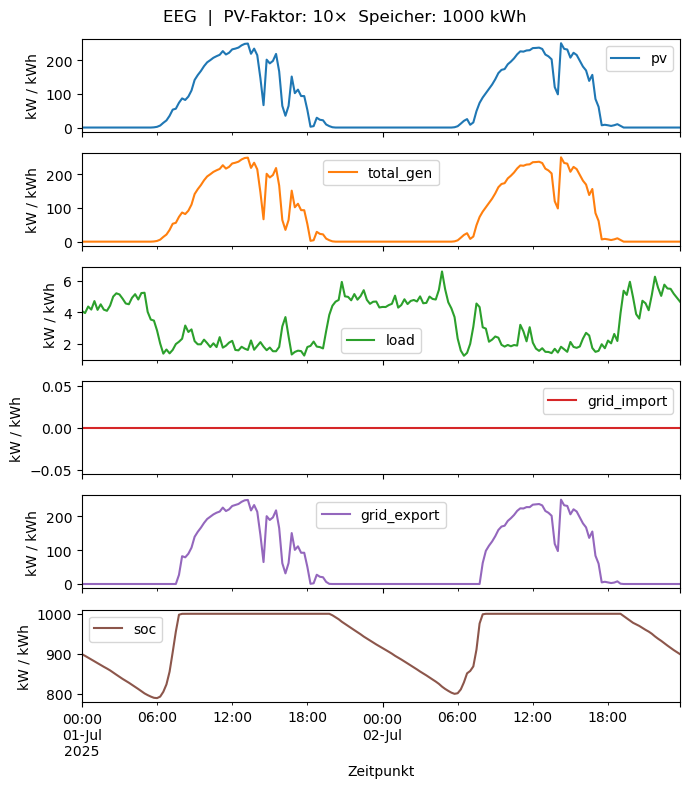

In [7]:
fig, ax = M.plot_timeseries(figsize=(7,8), start='2025-07-01', end='2025-07-02')

In [8]:
pv_scales    = np.arange(5, 105, 5)    # mögliche PV-Skalierungen
storage_grid = np.arange(0, 2100, 100) # mögliche Speichergrößen in kWh

target    = 'days_self_sufficient'  # Zielgröße aus dem Simulations-Summary
threshold = 0.75                    # mindestens 75 % der Tage autark
op        = '>='

opt_df = M.optimize_min_cost(
    pv_scales, storage_grid,
    threshold_metric=target, threshold=threshold, op=op,
    c_rate=1, roundtrip_eff=1,
)

Cost-optimal search: 100%|██████████| 420/420 [01:35<00:00,  4.39it/s]



Gefunden: 296 Lösungen mit days_self_sufficient >= 0.75.
Beste Lösung: pv_scale=25.0, storage_kwh=600.0, Kosten=510000


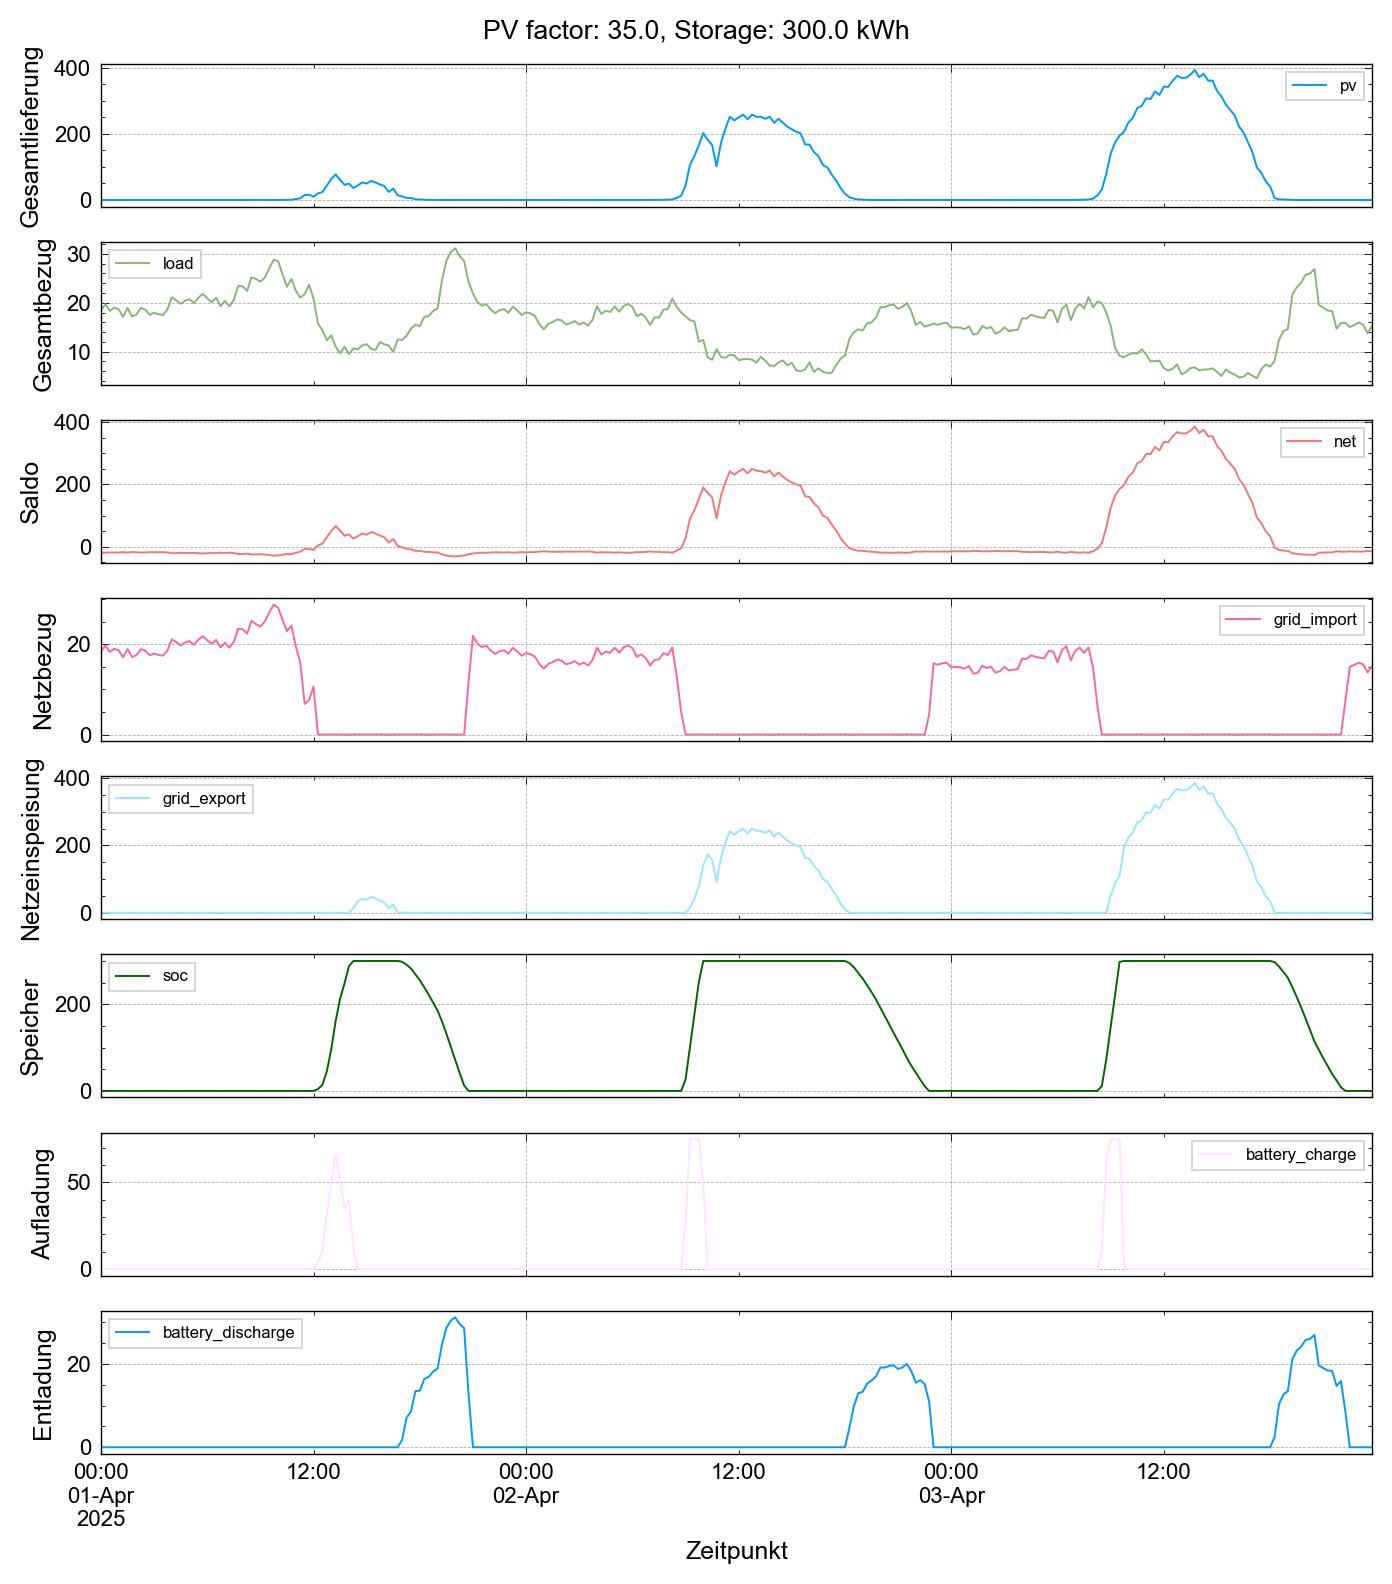

In [ ]:
fig, axes = M.plot_timeseries(M.best_run, figsize=(7, 8), start='2025-04-01', end='2025-04-03')

col_labels = {
    'pv':                'PV-Erzeugung',
    'total_gen':         'Gesamterzeugung',
    'load':              'Gesamtbezug',
    'net':               'Saldo',
    'grid_import':       'Netzbezug',
    'grid_export':       'Netzeinspeisung',
    'soc':               'Speicher-SoC',
    'battery_charge':    'Aufladung',
    'battery_discharge': 'Entladung',
}
for ax in axes:
    col = ax.get_ylabel()          # plot sets ylabel to column name by default
    ax.set_ylabel(col_labels.get(col, col) + ' [kWh]')

plt.tight_layout()